In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

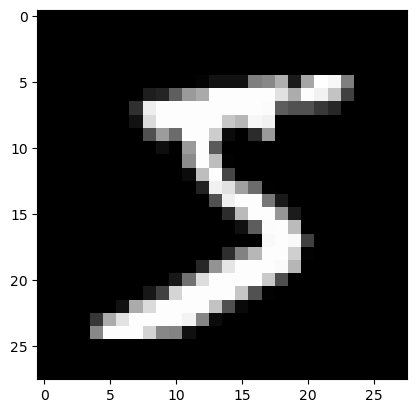

In [3]:
plt.imshow(x_train[0], cmap="gray")
plt.show()

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same",
           input_shape=(28,28,1)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation="relu", padding="same"),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(10, activation="softmax")
])

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9268 - loss: 0.2394 - val_accuracy: 0.9793 - val_loss: 0.0658
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9731 - loss: 0.0914 - val_accuracy: 0.9872 - val_loss: 0.0455
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9800 - loss: 0.0679 - val_accuracy: 0.9872 - val_loss: 0.0394
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9831 - loss: 0.0553 - val_accuracy: 0.9893 - val_loss: 0.0386
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9858 - loss: 0.0457 - val_accuracy: 0.9904 - val_loss: 0.0350
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9883 - loss: 0.0379 - val_accuracy: 0.9893 - val_loss: 0.0385
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9904 - loss: 0.0332 - val_accuracy: 0.9907 - val_loss: 0.0404
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9906 - loss: 0

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(test_accuracy)
test_loss

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9922 - loss: 0.0298
0.9922000169754028


0.029799755662679672

In [11]:
from sklearn.metrics import classification_report
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(x_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
cm

array([[ 979,    0,    0,    0,    0,    0,    1,    0,    0,    0],
       [   0, 1132,    1,    2,    0,    0,    0,    0,    0,    0],
       [   1,    1, 1026,    0,    0,    0,    1,    2,    1,    0],
       [   0,    0,    0, 1005,    0,    3,    0,    1,    1,    0],
       [   0,    0,    0,    0,  981,    0,    0,    0,    0,    1],
       [   2,    1,    0,    2,    0,  884,    2,    0,    1,    0],
       [   4,    2,    0,    0,    1,    5,  946,    0,    0,    0],
       [   1,    6,    7,    0,    0,    0,    0, 1012,    1,    1],
       [   1,    0,    1,    0,    0,    1,    0,    0,  969,    2],
       [   2,    0,    1,    0,    9,    4,    0,    1,    4,  988]])

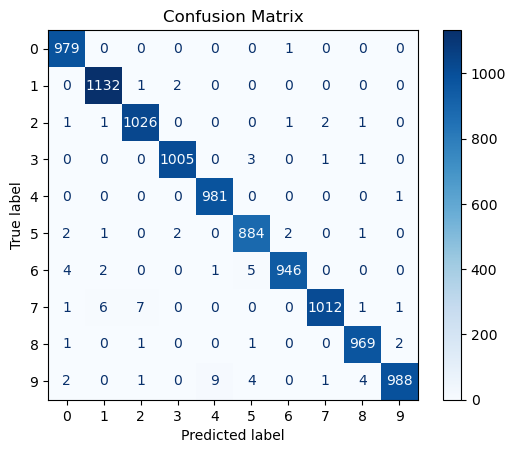

In [14]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

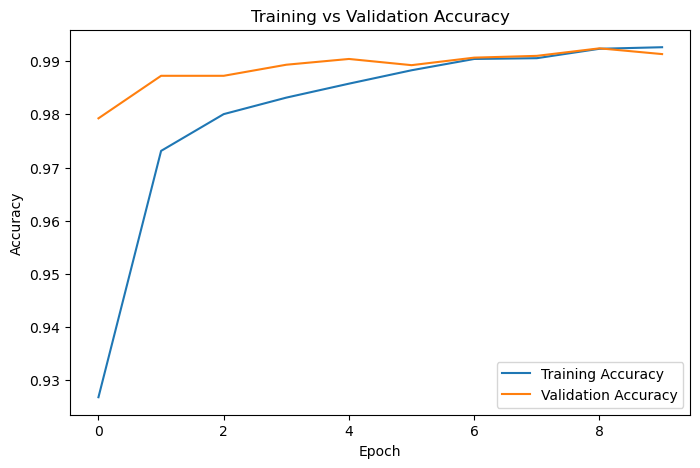

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

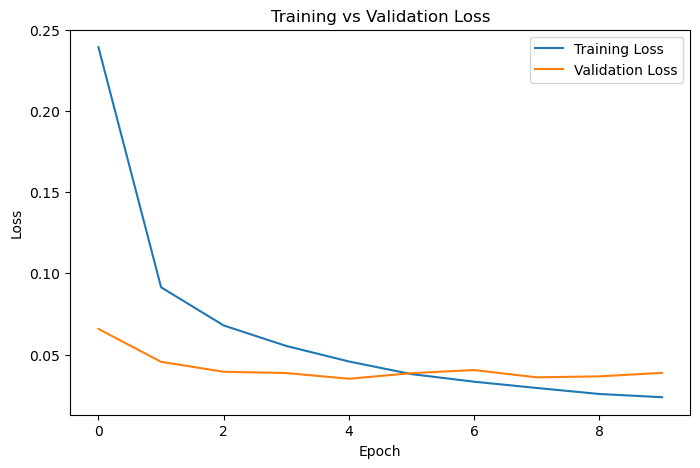

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()